In [1]:
import pandas as pd

# Cargar la base de datos
df1 = pd.read_csv('dataset_prueba.csv')

# Mostrar información básica y las primeras filas
print("Información del DataFrame:")
df1.info()
print("\nPrimeras 5 filas:")
print(df1.head())



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299997 entries, 0 to 299996
Data columns (total 56 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   last_date_of_month      298296 non-null  object 
 1   arpu                    299997 non-null  float64
 2   onnet_mou               286823 non-null  float64
 3   offnet_mou              286823 non-null  float64
 4   roam_ic_mou             286823 non-null  float64
 5   roam_og_mou             286823 non-null  float64
 6   loc_og_t2t_mou          286823 non-null  float64
 7   loc_og_t2m_mou          286823 non-null  float64
 8   loc_og_t2f_mou          286823 non-null  float64
 9   loc_og_t2c_mou          286823 non-null  float64
 10  loc_og_mou              286823 non-null  float64
 11  std_og_t2t_mou          286823 non-null  float64
 12  std_og_t2m_mou          286823 non-null  float64
 13  std_og_t2f_mou          286823 non-null  float6

In [2]:
import pandas as pd

# Cargar la base de datos data_dict.csv
df2 = pd.read_csv('data_dict.csv')

# Mostrar información básica y las primeras filas
print("Información del DataFrame df2:")
df2.info()
print("\nPrimeras filas de df2:")
print(df2.head())


Información del DataFrame df2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Acronyms      34 non-null     object
 1   Descriptions  34 non-null     object
dtypes: object(2)
memory usage: 676.0+ bytes

Primeras filas de df2:
        Acronyms                                       Descriptions
0  MOBILE_NUMBER                              Customer phone number
1      CIRCLE_ID  Telecom circle area to which the customer belo...
2            LOC           Local calls - within same telecom circle
3            STD             STD calls - outside the calling circle
4             IC                                     Incoming calls


In [3]:
############## EDA ############

In [4]:
# Crear los conjuntos de entrenamiento y prueba
df_train = df1[df1['last_date_of_month'].isin(['6/30/2014', '7/31/2014'])]
df_test = df1[df1['last_date_of_month'] == '8/31/2014']

<module 'matplotlib.pyplot' from 'C:\\Users\\USUARIO\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>


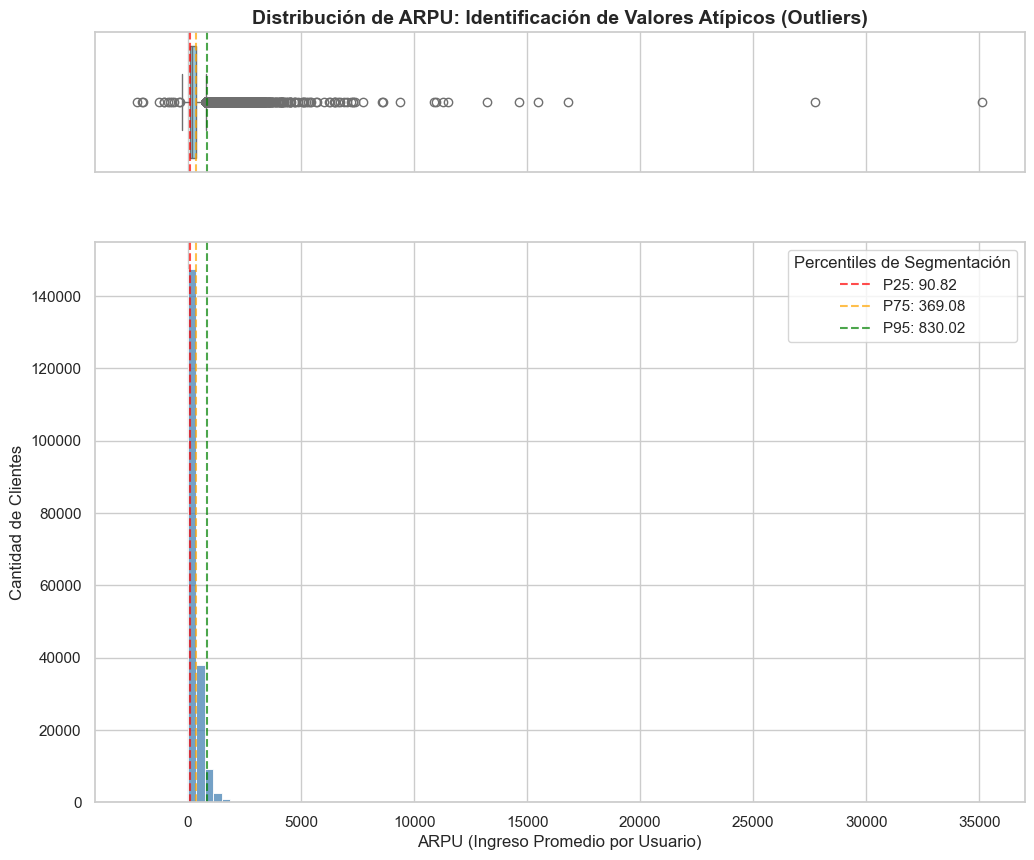

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos (boxplot e histograma)
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": (.2, .8)})

# Boxplot para visualizar claramente los outliers
sns.boxplot(x=df_train['arpu'], ax=ax[0], color='skyblue')
ax[0].set_title('Distribución de ARPU: Identificación de Valores Atípicos (Outliers)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('')

# Histograma para ver la concentración de los datos
sns.histplot(df_train['arpu'], bins=100, ax=ax[1], kde=False, color='steelblue')
ax[1].set_xlabel('ARPU (Ingreso Promedio por Usuario)', fontsize=12)
ax[1].set_ylabel('Cantidad de Clientes', fontsize=12)

# Añadir líneas verticales para los cortes de los percentiles propuestos (25%, 75%, 95%)
q25 = df_train['arpu'].quantile(0.25)
q75 = df_train['arpu'].quantile(0.75)
q95 = df_train['arpu'].quantile(0.95)

for axis in ax:
    axis.axvline(q25, color='red', linestyle='--', alpha=0.7, label=f'P25: {q25:.2f}')
    axis.axvline(q75, color='orange', linestyle='--', alpha=0.7, label=f'P75: {q75:.2f}')
    axis.axvline(q95, color='green', linestyle='--', alpha=0.7, label=f'P95: {q95:.2f}')

ax[1].legend(title='Percentiles de Segmentación', loc='upper right')

print(plt)

In [5]:
import pandas as pd
import numpy as np

# Analizar la distribución de ARPU
print("Estadísticas descriptivas de ARPU en df_train:")
print(df_train['arpu'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

q25 = df_train['arpu'].quantile(0.25)
q75 = df_train['arpu'].quantile(0.75)
q95 = df_train['arpu'].quantile(0.95)

def segment_arpu(x):
    if x <= q25:
        return 'Bajo'
    elif x <= q75:
        return 'Medio'
    elif x <= q95:
        return 'Alto'
    else:
        return 'Premium'

df_train['arpu_segment'] = df_train['arpu'].apply(segment_arpu)

# Analizar distribución en cada segmento
segment_analysis = df_train.groupby('arpu_segment').agg(
    Clientes=('mobile_number', 'count'),
    ARPU_Promedio=('arpu', 'mean'),
    ARPU_Min=('arpu', 'min'),
    ARPU_Max=('arpu', 'max'),
    Tasa_Churn=('churn', 'mean')
).reset_index()

segment_analysis['%_del_Total'] = (segment_analysis['Clientes'] / segment_analysis['Clientes'].sum()) * 100

print("\nAnálisis de Segmentos:")
print(segment_analysis)

Estadísticas descriptivas de ARPU en df_train:
count    199397.000000
mean        281.608245
std         333.484903
min       -2258.709000
25%          90.824000
50%         195.489000
75%         369.082000
90%         619.619400
95%         830.016600
99%        1421.111320
max       35145.834000
Name: arpu, dtype: float64

Análisis de Segmentos:
        arpu_segment  Clientes  ARPU_Promedio  ARPU_Min   ARPU_Max  \
0      1. Bajo (Low)     49850      40.681504 -2258.709     90.824   
1  2. Medio (Medium)     99698     205.994986    90.825    369.082   
2     3. Alto (High)     39879     532.809319   369.084    830.016   
3         4. Premium      9970    1237.580269   830.019  35145.834   

   Tasa_Churn  %_del_Total  
0    0.027703    25.000376  
1    0.008375    49.999749  
2    0.006821    19.999799  
3    0.006319     5.000075  


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2724\2035962100.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['arpu_segment'] = df_train['arpu'].apply(segment_arpu)


In [8]:
###########33 CREACION DE 2 VARIABLES ###########

In [9]:
import pandas as pd
import numpy as np

# 1. Crear feature: Monto Promedio por Recarga
df_train['monto_promedio_recarga'] = np.where(df_train['total_rech_num'] > 0, 
                                              df_train['total_rech_amt'] / df_train['total_rech_num'], 
                                              0)

# 2. Crear feature: Volumen Total de Datos (MB)
df_train['vol_total_datos_mb'] = df_train['vol_2g_mb'] + df_train['vol_3g_mb']

# Analizar el valor de las nuevas variables respecto al churn
analisis_nuevas_vars = df_train.groupby('churn')[['monto_promedio_recarga', 'vol_total_datos_mb']].mean()

print("Promedio de las nuevas variables según estado de Churn:")
print(analisis_nuevas_vars)

Promedio de las nuevas variables según estado de Churn:
       monto_promedio_recarga  vol_total_datos_mb
churn                                            
0                   47.168524          178.966302
1                   32.817349           48.428742


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2724\1789571690.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['monto_promedio_recarga'] = np.where(df_train['total_rech_num'] > 0,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2724\1789571690.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['vol_total_datos_mb'] = df_train['vol_2g_mb'] + df_train['vol_3g_mb']


In [10]:
##### ANALISIS DE CHURN ####

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2724\1206427015.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_month.index, y=churn_by_month['Tasa_Churn_%'], ax=axes[0, 0], palette='Reds')
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2724\1206427015.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='churn', y='arpu', data=df_valid_dates, ax=axes[0, 1], palette='Blues')
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_2724\1206427015.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['No Churn (0)', 'Churn (1)'])
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_27

<module 'matplotlib.pyplot' from 'C:\\Users\\USUARIO\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>


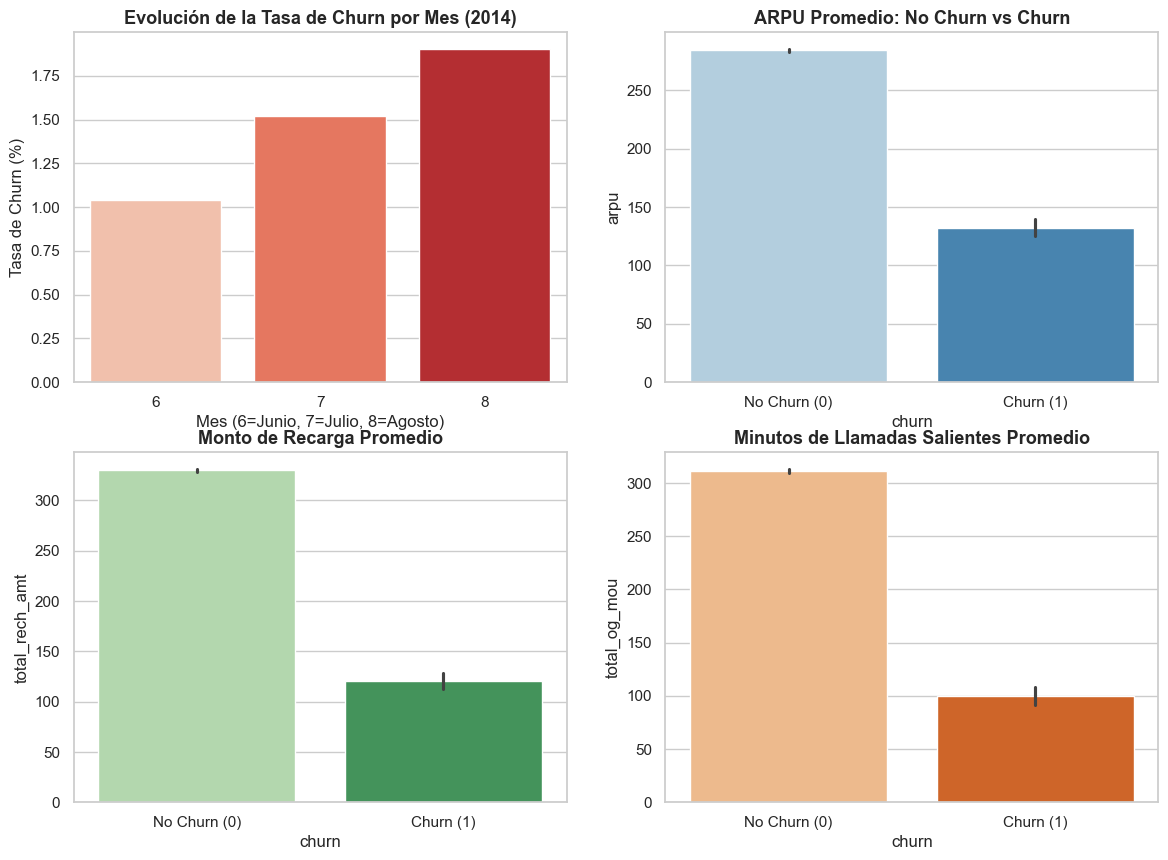

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('dataset_prueba.csv')

# Filtrar nulos en la fecha y extraer el mes
df_valid_dates = df.dropna(subset=['last_date_of_month']).copy()
df_valid_dates['last_date_of_month'] = pd.to_datetime(df_valid_dates['last_date_of_month'])
df_valid_dates['month'] = df_valid_dates['last_date_of_month'].dt.month

# 1. Comportamiento del churn por mes
churn_by_month = df_valid_dates.groupby('month')['churn'].agg(['mean', 'count'])
churn_by_month['mean'] = churn_by_month['mean'] * 100  # Convertir a porcentaje
churn_by_month.rename(columns={'mean': 'Tasa_Churn_%', 'count': 'Total_Clientes'}, inplace=True)

# 2. Comparación de variables clave (Churn vs No Churn)
# Seleccionamos variables representativas: Ingresos, Recargas, Llamadas (salida y entrada), Datos
key_vars = ['arpu', 'total_rech_amt', 'total_rech_num', 'total_og_mou', 'total_ic_mou', 'vol_2g_mb', 'vol_3g_mb']
comp_churn = df_valid_dates.groupby('churn')[key_vars].mean().T
comp_churn.columns = ['No Churn (Se quedan)', 'Churn (Se fugan)']
comp_churn['Diferencia %'] = ((comp_churn['Churn (Se fugan)'] - comp_churn['No Churn (Se quedan)']) / comp_churn['No Churn (Se quedan)']) * 100

# 3. Visualizaciones
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Tasa de Churn por mes
sns.barplot(x=churn_by_month.index, y=churn_by_month['Tasa_Churn_%'], ax=axes[0, 0], palette='Reds')
axes[0, 0].set_title('Evolución de la Tasa de Churn por Mes (2014)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Mes (6=Junio, 7=Julio, 8=Agosto)')
axes[0, 0].set_ylabel('Tasa de Churn (%)')

# Gráfico 2: ARPU
sns.barplot(x='churn', y='arpu', data=df_valid_dates, ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('ARPU Promedio: No Churn vs Churn', fontsize=13, fontweight='bold')
axes[0, 1].set_xticklabels(['No Churn (0)', 'Churn (1)'])

# Gráfico 3: Monto de Recarga
sns.barplot(x='churn', y='total_rech_amt', data=df_valid_dates, ax=axes[1, 0], palette='Greens')
axes[1, 0].set_title('Monto de Recarga Promedio', fontsize=13, fontweight='bold')
axes[1, 0].set_xticklabels(['No Churn (0)', 'Churn (1)'])

# Gráfico 4: Minutos de Salida (Llamadas)
sns.barplot(x='churn', y='total_og_mou', data=df_valid_dates, ax=axes[1, 1], palette='Oranges')
axes[1, 1].set_title('Minutos de Llamadas Salientes Promedio', fontsize=13, fontweight='bold')
axes[1, 1].set_xticklabels(['No Churn (0)', 'Churn (1)'])

print(plt)



In [12]:
print("1. Tasa de Churn por mes:")
print(churn_by_month)
print("\n2. Comparación de clientes (Promedios) - Churn vs No Churn:")
print(comp_churn.round(2))

1. Tasa de Churn por mes:
       Tasa_Churn_%  Total_Clientes
month                              
6          1.038010           99999
7          1.522163           99398
8          1.902951           98899

2. Comparación de clientes (Promedios) - Churn vs No Churn:
                No Churn (Se quedan)  Churn (Se fugan)  Diferencia %
arpu                          284.08            132.24        -53.45
total_rech_amt                329.84            120.72        -63.40
total_rech_num                  7.60              3.44        -54.70
total_og_mou                  311.39             99.47        -68.06
total_ic_mou                  203.88             58.82        -71.15
vol_2g_mb                      52.00             11.34        -78.19
vol_3g_mb                     130.78             33.65        -74.27


In [13]:
### Analisis adicional ####v

<module 'matplotlib.pyplot' from 'C:\\Users\\USUARIO\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>


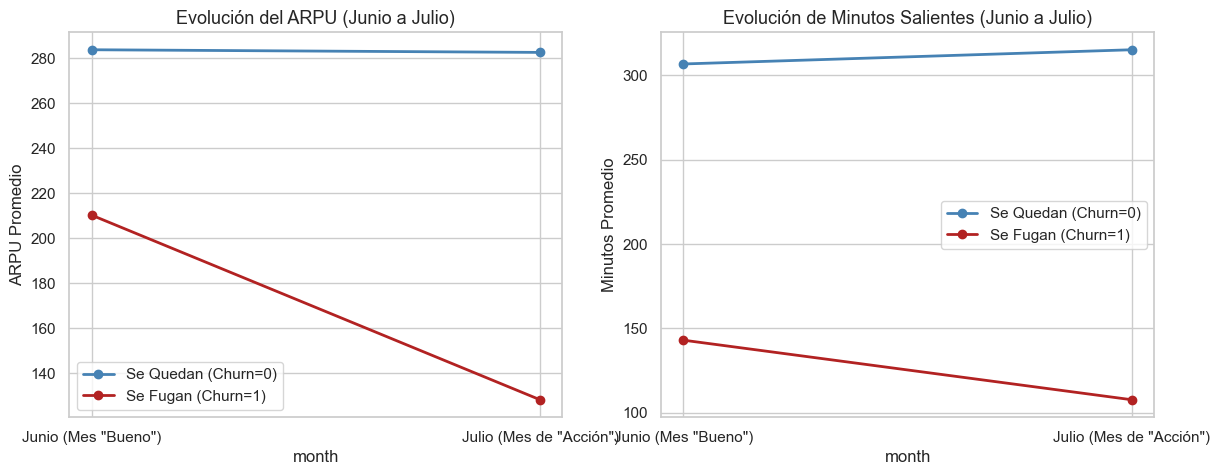

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('dataset_prueba.csv')
df = df.dropna(subset=['last_date_of_month']).copy()
df['last_date_of_month'] = pd.to_datetime(df['last_date_of_month'])
df['month'] = df['last_date_of_month'].dt.month

# Filtrar solo Junio (6) y Julio (7) para ver la trayectoria antes de la fuga
df_train_traj = df[df['month'].isin([6, 7])].copy()

# Calcular el ARPU promedio y Minutos Salientes por mes según el estado de churn
trajectory_arpu = df_train_traj.groupby(['churn', 'month'])['arpu'].mean().unstack()
trajectory_mou = df_train_traj.groupby(['churn', 'month'])['total_og_mou'].mean().unstack()

# Preparar la visualización de la "Fase de Acción"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Trayectoria ARPU
trajectory_arpu.T.plot(ax=axes[0], marker='o', linewidth=2, color=['steelblue', 'firebrick'])
axes[0].set_title('Evolución del ARPU (Junio a Julio)', fontsize=13)
axes[0].set_xticks([6, 7])
axes[0].set_xticklabels(['Junio (Mes "Bueno")', 'Julio (Mes de "Acción")'])
axes[0].legend(['Se Quedan (Churn=0)', 'Se Fugan (Churn=1)'])
axes[0].set_ylabel('ARPU Promedio')

# Gráfico 2: Trayectoria Minutos
trajectory_mou.T.plot(ax=axes[1], marker='o', linewidth=2, color=['steelblue', 'firebrick'])
axes[1].set_title('Evolución de Minutos Salientes (Junio a Julio)', fontsize=13)
axes[1].set_xticks([6, 7])
axes[1].set_xticklabels(['Junio (Mes "Bueno")', 'Julio (Mes de "Acción")'])
axes[1].legend(['Se Quedan (Churn=0)', 'Se Fugan (Churn=1)'])
axes[1].set_ylabel('Minutos Promedio')

print(plt)

In [16]:

# Calcular el porcentaje de caída para los que se fugan
arpu_drop = ((trajectory_arpu.loc[1, 7] - trajectory_arpu.loc[1, 6]) / trajectory_arpu.loc[1, 6]) * 100
mou_drop = ((trajectory_mou.loc[1, 7] - trajectory_mou.loc[1, 6]) / trajectory_mou.loc[1, 6]) * 100

print(f"Caída de ARPU en clientes que hacen churn de Junio a Julio: {arpu_drop:.1f}%")
print(f"Caída de Minutos en clientes que hacen churn de Junio a Julio: {mou_drop:.1f}%")

Caída de ARPU en clientes que hacen churn de Junio a Julio: -39.0%
Caída de Minutos en clientes que hacen churn de Junio a Julio: -24.7%


In [ ]:
#### modelo #####

In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Cargar y preparar los datos según la división acordada
df = pd.read_csv('dataset_prueba.csv')
df = df.dropna(subset=['last_date_of_month']).copy()

# Dividir en Train y Test
df_train = df[df['last_date_of_month'].isin(['6/30/2014', '7/31/2014'])].copy()
df_test = df[df['last_date_of_month'] == '8/31/2014'].copy()

# 2. Preprocesamiento / Limpieza acordada
columnas_a_eliminar = ['mobile_number', 'last_date_of_month', 'date_of_last_rech', 'date_of_last_rech_data']

# Separar features y target
X_train = df_train.drop(columns=columnas_a_eliminar + ['churn'])
y_train = df_train['churn']

X_test = df_test.drop(columns=columnas_a_eliminar + ['churn'])
y_test = df_test['churn']

# Imputar nulos con 0 (estrategia definida para nulos de telecomunicaciones)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# 3. Modelado: Random Forest Classifier
# Usamos class_weight='balanced' para manejar el gran desbalance de la clase churn (1.2%)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predicciones y Probabilidades en Test
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1] # Probabilidad de clase 1 (Churn)

# 4. Evaluación Tradicional
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score en Test: {auc:.4f}")

# 5. Evaluación de Negocio (Top 2000 Clientes)
# Crear un dataframe con los resultados
resultados_test = pd.DataFrame({
    'y_real': y_test,
    'probabilidad_churn': y_proba
})

# Ordenar de mayor a menor probabilidad y tomar los 2000 primeros
top_2000_contactos = resultados_test.sort_values(by='probabilidad_churn', ascending=False).head(2000)

# Calcular métricas de negocio
verdaderos_churners_encontrados = top_2000_contactos['y_real'].sum()
falsas_alarmas = 2000 - verdaderos_churners_encontrados

costo_campana = 2000 * 1000  # $1,000 CLP por contacto
clientes_retenidos_exito = verdaderos_churners_encontrados * 0.10
ingresos_recuperados = clientes_retenidos_exito * 30000
beneficio_neto = ingresos_recuperados - costo_campana
roi = (beneficio_neto / costo_campana) * 100


ROC-AUC Score en Test: 0.8775


In [18]:

print("\n--- EVALUACIÓN DE NEGOCIO (CAMPAÑA TOP 2000) ---")
print(f"Total de clientes contactados: 2000")
print(f"Verdaderos Churners encontrados en la lista: {verdaderos_churners_encontrados}")
print(f"Precisión en el Top 2000: {(verdaderos_churners_encontrados/2000)*100:.2f}%")
print(f"\nCostos de la campaña: ${costo_campana:,.0f} CLP")
print(f"Clientes retenidos con éxito (10%): {clientes_retenidos_exito:.0f}")
print(f"Ingresos recuperados: ${ingresos_recuperados:,.0f} CLP")
print(f"BENEFICIO NETO (Profit): ${beneficio_neto:,.0f} CLP")
print(f"ROI de la campaña: {roi:.2f}%")


--- EVALUACIÓN DE NEGOCIO (CAMPAÑA TOP 2000) ---
Total de clientes contactados: 2000
Verdaderos Churners encontrados en la lista: 619
Precisión en el Top 2000: 30.95%

Costos de la campaña: $2,000,000 CLP
Clientes retenidos con éxito (10%): 62
Ingresos recuperados: $1,857,000 CLP
BENEFICIO NETO (Profit): $-143,000 CLP
ROI de la campaña: -7.15%


In [ ]:
#### PRIORIZACION #########

In [23]:
# ==========================================
# 4. SCORING Y RANKING (ESTRATEGIA DE NEGOCIO)
# ==========================================
# No pedimos un 0 o 1, pedimos la PROBABILIDAD de que el cliente sea 1 (Churn)
probabilidades_churn = rf_model.predict_proba(X_test)[:, 1]

# Crear un DataFrame con los resultados y el identificador del cliente
resultados_campana = pd.DataFrame({
    'numero_cliente': df_test['mobile_number'],
    'churn_real': y_test,
    'probabilidad_fuga': probabilidades_churn
})

# ESTRATEGIA CLAVE: Ordenar de mayor a menor riesgo y seleccionar el Top 2000
top_2000_clientes = resultados_campana.sort_values(by='probabilidad_fuga', ascending=False).head(2000)

# Mostrar una muestra de cómo se ve la lista que irá al Call Center
print("--- MUESTRA DE LA LISTA DE CONTACTO (TOP 5) ---")
print(top_2000_clientes[['numero_cliente', 'probabilidad_fuga']].head())

# ==========================================
# 5. EVALUACIÓN FINANCIERA (ROI Y BENEFICIO)
# ==========================================
# Variables financieras definidas por el negocio
limite_contactos = 2000
costo_por_contacto = 1000
tasa_exito_retencion = 0.10
valor_cliente_retenido = 30000

# Cuántos de los seleccionados se iban a fugar en realidad
verdaderos_churners = top_2000_clientes['churn_real'].sum()

# Cálculos
costo_total_campana = limite_contactos * costo_por_contacto
clientes_salvados = verdaderos_churners * tasa_exito_retencion
ingresos_recuperados = clientes_salvados * valor_cliente_retenido
beneficio_neto = ingresos_recuperados - costo_total_campana
roi = (beneficio_neto / costo_total_campana) * 100

# Imprimir el reporte final para la gerencia
print("\n" + "="*50)
print("REPORTE FINANCIERO DE LA CAMPAÑA DE RETENCIÓN")
print("="*50)
print(f"Total de clientes a contactar: {limite_contactos}")
print(f"Verdaderos churners en la lista Top 2000: {verdaderos_churners}")
print(f"Precisión operativa (Hit Rate): {(verdaderos_churners/limite_contactos)*100:.1f}%")
print("-" * 50)
print(f"Inversión de la campaña:     - ${costo_total_campana:,.0f} CLP")
print(f"Clientes retenidos (10%):      {clientes_salvados:.0f} clientes")
print(f"Ingresos salvados:           + ${ingresos_recuperados:,.0f} CLP")
print("-" * 50)
print(f"BENEFICIO NETO:              ${beneficio_neto:,.0f} CLP")
print(f"ROI:                         {roi:.1f}%")
print("="*50)

--- MUESTRA DE LA LISTA DE CONTACTO (TOP 5) ---
       numero_cliente  probabilidad_fuga
68280      7001678157           0.981722
21676      7001367644           0.981722
43291      7001369951           0.981722
90369      7002266626           0.981722
7693       7000670592           0.981706

REPORTE FINANCIERO DE LA CAMPAÑA DE RETENCIÓN
Total de clientes a contactar: 2000
Verdaderos churners en la lista Top 2000: 619
Precisión operativa (Hit Rate): 30.9%
--------------------------------------------------
Inversión de la campaña:     - $2,000,000 CLP
Clientes retenidos (10%):      62 clientes
Ingresos salvados:           + $1,857,000 CLP
--------------------------------------------------
BENEFICIO NETO:              $-143,000 CLP
ROI:                         -7.1%
